<a href="https://colab.research.google.com/github/cozen03/2026-Programming/blob/main/%EB%A7%88%EB%8A%98%EA%BB%8D%EC%A7%88_%EB%B9%84%EB%8B%90%EB%A7%8C%EB%93%A4%EA%B8%B0_%EA%B1%B4%EC%A1%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (10.2 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and direct

1. 배합비에 따른 물성 예측


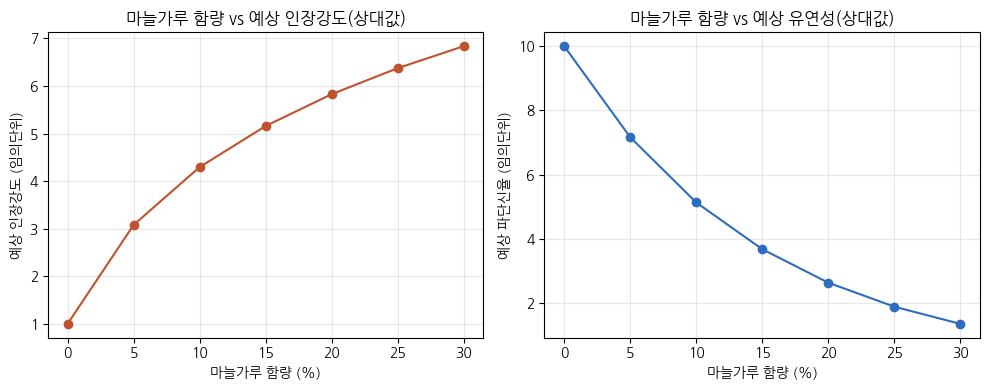


  마늘가루 함량(%) |      예상 강도 |     예상 유연성
           0 |       1.00 |      10.00
           5 |       3.08 |       7.17
          10 |       4.30 |       5.13
          15 |       5.16 |       3.68
          20 |       5.83 |       2.64
          25 |       6.38 |       1.89
          30 |       6.84 |       1.35

2. 건조 완료 자동 판단 시뮬레이션
=== 가상 건조 데이터 (시간(분), 습도(%)) ===
    0분 | 습도  48.0%
   10분 | 습도  43.3%
   20분 | 습도  39.0%
   30분 | 습도  35.2%
   40분 | 습도  31.9%
   50분 | 습도  28.8%
   60분 | 습도  26.1%
   70분 | 습도  23.7%
   80분 | 습도  21.5%
   90분 | 습도  19.6%
  100분 | 습도  17.8%
  110분 | 습도  16.3%
  120분 | 습도  14.9%
  130분 | 습도  13.6%
  140분 | 습도  12.5%
  150분 | 습도  11.5%
  160분 | 습도  10.6%
  170분 | 습도   9.8%
  180분 | 습도   9.1%
  190분 | 습도   8.4%
  200분 | 습도   7.9%
  210분 | 습도   7.4%
  220분 | 습도   6.9%
  230분 | 습도   6.5%
  240분 | 습도   6.1%
  250분 | 습도   5.8%
  260분 | 습도   5.5%
  270분 | 습도   5.2%
  280분 | 습도   5.0%
  290분 | 습도   4.8%

[판단 결과] 230분 시점에 건조 완료로 판단됨


In [5]:
# -*- coding: utf-8 -*-
"""
마늘껍질 비닐(전분 기반 바이오플라스틱) 탐구 - 보조 시뮬레이션 코드
====================================================================
"""

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 나눔고딕 폰트를 찾아서 적용 (설치되어 있으면 자동 인식)
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
try:
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'NanumGothic'
except FileNotFoundError:
    print("[안내] 나눔고딕 폰트를 찾지 못했습니다.")
    print("아래 명령을 먼저 실행하고 런타임을 재시작하세요:")
    print("  !sudo apt-get install -y fonts-nanum")
    print("  !sudo fc-cache -fv")

plt.rcParams['axes.unicode_minus'] = False


# ============================================================
# 1) 배합비(마늘가루 함량)에 따른 물성 예측 모델
# ============================================================

def predict_properties(garlic_content_pct):
    """
    마늘가루 함량(%)을 입력받아 예상 인장강도(임의단위)와
    예상 파단신율(유연성, 임의단위)을 계산하는 간이 예측 함수.
    """
    import math

    # 강도는 함량이 늘수록 완만하게 증가 (로그형 증가로 근사)
    strength_index = 1 + 3 * math.log(1 + garlic_content_pct / 5)

    # 유연성(파단신율)은 함량이 늘수록 감소 (지수형 감소로 근사)
    elongation_index = 10 * math.exp(-garlic_content_pct / 15)

    return strength_index, elongation_index


def plot_property_trend():
    """대조군(0%)~실험군(30%) 범위에서 물성 예측 경향을 그래프로 시각화"""
    contents = [0, 5, 10, 15, 20, 25, 30]
    strengths = []
    elongations = []

    for c in contents:
        s, e = predict_properties(c)
        strengths.append(s)
        elongations.append(e)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].plot(contents, strengths, 'o-', color='#c0522d')
    axes[0].set_title('마늘가루 함량 vs 예상 인장강도(상대값)')
    axes[0].set_xlabel('마늘가루 함량 (%)')
    axes[0].set_ylabel('예상 인장강도 (임의단위)')
    axes[0].grid(alpha=0.3)

    axes[1].plot(contents, elongations, 'o-', color='#2d6dc0')
    axes[1].set_title('마늘가루 함량 vs 예상 유연성(상대값)')
    axes[1].set_xlabel('마늘가루 함량 (%)')
    axes[1].set_ylabel('예상 파단신율 (임의단위)')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('property_trend.png', dpi=150)
    plt.show()  # 코랩 노트북 화면에 그래프 바로 출력
    print()
    print(f"{'마늘가루 함량(%)':>12} | {'예상 강도':>10} | {'예상 유연성':>10}")
    for c, s, e in zip(contents, strengths, elongations):
        print(f"{c:>12} | {s:>10.2f} | {e:>10.2f}")


# ============================================================
# 2) 온습도 센서 데이터를 이용한 건조 완료 자동 판단 로직
# ============================================================

def is_drying_complete(humidity_log, threshold=8.0, stable_minutes=30):
    """
    시간에 따른 습도(%) 기록 리스트를 받아 건조 완료 여부를 판단.

    판단 기준(예시 규칙):
      - 습도가 threshold(기본 8%) 이하로 떨어지고,
      - 그 상태가 stable_minutes(기본 30분) 이상 유지되면 '건조 완료'로 판단

    humidity_log: [(경과시간(분), 습도(%)), ...] 형태의 리스트
    """
    below_threshold_start = None

    for time_min, humidity in humidity_log:
        if humidity <= threshold:
            if below_threshold_start is None:
                below_threshold_start = time_min
            elif time_min - below_threshold_start >= stable_minutes:
                return True, time_min  # 이 시점에 건조 완료로 판단
        else:
            below_threshold_start = None  # 다시 기준치를 넘으면 리셋

    return False, None


def simulate_drying_process():
    """
    실제 센서가 없는 상태이므로, 시간이 지날수록 습도가 서서히
    떨어지는 가상의 건조 데이터를 만들어 판단 로직을 함.
    (추후 실제 온습도 센서와 연결하면 humidity_log 부분을
     실측 데이터로 교체하기만 하면 됨.)
    """
    import math

    fake_log = []
    start_humidity = 45.0
    for t in range(0, 300, 10):  # 0분 ~ 300분, 10분 간격 측정
        # 지수적으로 감소하는 가상 습도 곡선 + 약간의 잡음 방지를 위해 단순화
        humidity = start_humidity * math.exp(-t / 90) + 3
        fake_log.append((t, round(humidity, 1)))

    print("=== 가상 건조 데이터 (시간(분), 습도(%)) ===")
    for t, h in fake_log:
        print(f"  {t:>3}분 | 습도 {h:>5.1f}%")

    complete, complete_time = is_drying_complete(fake_log)

    print()
    if complete:
        print(f"[판단 결과] {complete_time}분 시점에 건조 완료로 판단됨")
    else:
        print("[판단 결과] 관찰 기간 내 건조 완료 기준을 충족하지 못함")


# ============================================================
# 실행부
# ============================================================

if __name__ == "__main__":
    print("1. 배합비에 따른 물성 예측")
    plot_property_trend()

    print()
    print("2. 건조 완료 자동 판단 시뮬레이션")
    simulate_drying_process()
